In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input,SimpleRNN, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import RandomForestClassifier
import random
from sklearn.preprocessing import StandardScaler
import json
import joblib 

data = pd.read_csv('dataset/KU-HAR/3.Time_domain_subsamples/KU-HAR_time_domain_subsamples_20750x300.csv', header=None)
#AŞAĞIDAKİ YORUM SATIRINI AÇIP ÜSTTEKİNİ YORUMA ALIRSANIZ YENİDEN TRİN TEST ETMEK GEREKİR. ÜSTTEKİ BÜTÜN VERİ SETİ. ALTTAKI SUBSET
#data = pd.read_csv('dataset/KU-HAR/3.Time_domain_subsamples/KU-HAR_time_domain_subsamples_subset.csv', header=None)
activity_labels = [
    'Stand',
    'Sit',
    'Talk-sit',
    'Talk-stand',
    'Stand-sit',
    'Lay',
    'Lay-stand',
    'Pick',
    'Jump',
    'Push-up',
    'Sit-up',
    'Walk',
    'Walk-backward',
    'Walk-circle',
    'Run',
    'Stair-up',
    'Stair-down',
    'Table-tennis'
]
#print(data.head())
sensor_data = data.iloc[:, :1800].to_numpy()
labels = data.iloc[:,1800].to_numpy()
#(sensor_data.shape[0])

In [2]:
timestemp_count = 300
feature_count = 6 # (acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z)
row_devided = sensor_data.reshape(sensor_data.shape[0], feature_count, timestemp_count)
X_3d = np.transpose(row_devided, (0, 2, 1))

print(X_3d.shape)

sensor_index = [
    (0, 300),    #acc_x
    (300, 600),   #acc_y
    (600, 900),   #acc_z
    (900, 1200),  #gyro_x
    (1200, 1500), #gyro_y
    (1500, 1800)  #gyro_z
]

feature_list = []

for i in range(sensor_data.shape[0]):
    segment_row = sensor_data[i]
    segment_features = []
    for j in range(len(sensor_index)):
        start, end = sensor_index[j]
        data = segment_row[start:end]

        segment_features.append(np.mean(data))
        segment_features.append(np.min(data))
        segment_features.append(np.max(data))
        segment_features.append(np.std(data))
        segment_features.append(np.median(data))
        segment_features.append(stats.median_abs_deviation(data)) # mad
        segment_features.append(np.sqrt(np.mean(data**2))) # rms
        segment_features.append(np.sum(data**2)) # enerji
        
        hist, _ = np.histogram(data, bins=10, density=True)
        segment_features.append(stats.entropy(hist))  # entropi

    feature_list.append(segment_features)

feature_extraction = pd.DataFrame(feature_list)
feature_names = ['mean', 'min', 'max', 'std', 'median', 'mad', 'rms', 'energy', 'entropy']
axis_name = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

column_names = [f'{axis}_{feat}' for axis in axis_name for feat in feature_names]
feature_extraction.columns = column_names
labels = labels.ravel()
num_classes = len(np.unique(labels))
# print(feature_extraction.shape)
# print(feature_extraction.head())

(20750, 300, 6)


In [3]:
y_one_hot = to_categorical(labels, num_classes=num_classes)

print(y_one_hot.shape)
print(y_one_hot[0])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_3d, y_one_hot, test_size=0.2, random_state=17, stratify=y_one_hot
) 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=17, stratify=y_train_val
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(20750, 18)
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(12450, 300, 6)
(4150, 300, 6)
(4150, 300, 6)


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
               precision    recall  f1-score   support

        Stand       0.32      0.33      0.32       377
          Sit       0.37      0.81      0.51       375
     Talk-sit       0.66      0.36      0.46       359
   Talk-stand       0.35      0.72      0.47       373
    Stand-sit       0.35      0.83      0.49       436
          Lay       0.57      0.07      0.12       363
    Lay-stand       0.32      0.16      0.21       352
         Pick       0.19      0.02      0.04       267
         Jump       0.39      0.41      0.40       133
      Push-up       0.00      0.00      0.00        96
       Sit-up       0.75      0.01      0.03       201
         Walk       0.27      0.36      0.31       176
Walk-backward       0.00      0.00      0.00        63
  Walk-circle       0.00      0.00      0.00        52
          Run       0.49      0.43      0.46       119
     Stair-up       0.18      0.04      0.06       160
   Stair-down       0.2

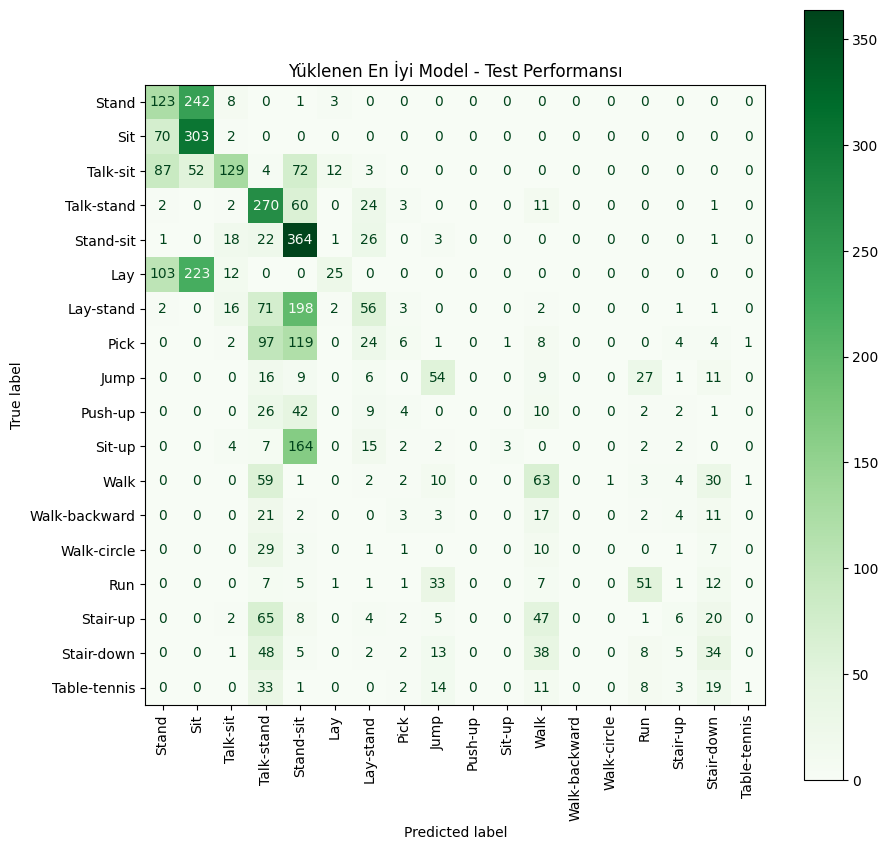

In [4]:
loaded_model = load_model('models_for_yontem2/kuhar/best_simple_rnn_model_kuhar_yontem2.keras')

y_test_pred_probs = loaded_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

print(classification_report(y_test_true, y_test_pred, target_names=activity_labels, zero_division=0))

figure, axes = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_test_true, 
    y_test_pred,
    display_labels=activity_labels, 
    cmap='Greens', 
    xticks_rotation='vertical', 
    ax=axes
)
plt.title('Yüklenen En İyi Model - Test Performansı')
plt.show()

130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
               precision    recall  f1-score   support

        Stand       0.00      0.00      0.00       377
          Sit       0.28      1.00      0.43       375
     Talk-sit       0.38      0.14      0.21       359
   Talk-stand       0.32      0.47      0.38       373
    Stand-sit       0.34      0.69      0.45       436
          Lay       0.52      0.10      0.17       363
    Lay-stand       0.34      0.19      0.24       352
         Pick       0.28      0.11      0.16       267
         Jump       0.45      0.41      0.43       133
      Push-up       0.00      0.00      0.00        96
       Sit-up       0.39      0.03      0.06       201
         Walk       0.21      0.61      0.32       176
Walk-backward       0.00      0.00      0.00        63
  Walk-circle       0.00      0.00      0.00        52
          Run       0.60      0.33      0.42       119
     Stair-up       0.10      0.03      0.05       160
   Stair-down       0.

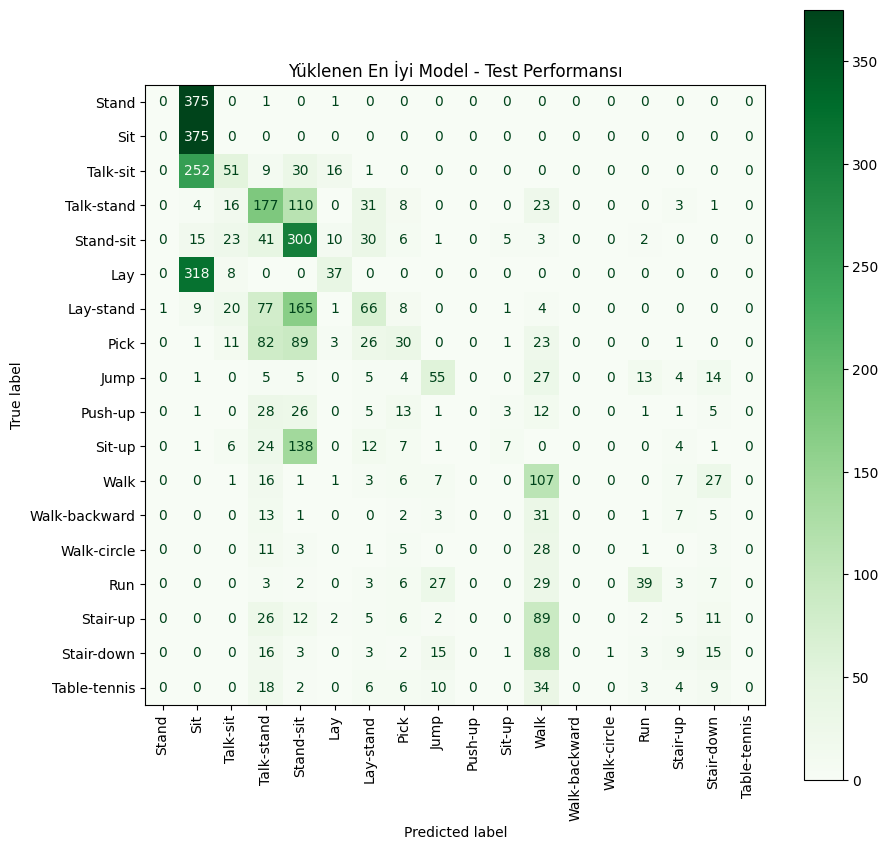

In [5]:
loaded_scaler = joblib.load('models_for_yontem2/kuhar/simple_rnn_with_fs_scaler.joblib')
with open('models_for_yontem2/kuhar/selected_feature_names.txt', 'r') as f:
    selected_feature_names = [line.strip() for line in f]

X_features_selected = feature_extraction[selected_feature_names]
X_features_selected_scaled = loaded_scaler.transform(X_features_selected)

features_3d = np.expand_dims(X_features_selected_scaled, axis=1)
features_corrert_size = np.tile(features_3d, (1, timestemp_count, 1))
X_combined = np.concatenate([X_3d, features_corrert_size], axis=2)

X_train_val_with_fs, X_test_with_fs, y_train_val_with_fs, y_test_with_fs = train_test_split(
    X_combined, y_one_hot, test_size=0.2, random_state=17, stratify=y_one_hot
) 
X_train_with_fs, X_val_with_fs, y_train_with_fs, y_val_with_fs = train_test_split(
    X_train_val_with_fs, y_train_val_with_fs, test_size=0.25, random_state=17, stratify=y_train_val_with_fs
)

model_with_fs= load_model('models_for_yontem2/kuhar/simple_rnn_with_fs_kuhar_yontem2.keras')

y_test_pred_probs_with_fs = model_with_fs.predict(X_test_with_fs)
y_test_pred_with_fs = np.argmax(y_test_pred_probs_with_fs, axis=1)
y_test_true_with_fs = np.argmax(y_test_with_fs, axis=1)

print(classification_report(y_test_true_with_fs, y_test_pred_with_fs, target_names=activity_labels, zero_division=0))

figure, axes = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(
    y_test_true_with_fs, 
    y_test_pred_with_fs,
    display_labels=activity_labels, 
    cmap='Greens', 
    xticks_rotation='vertical', 
    ax=axes
)
plt.title('Yüklenen En İyi Model - Test Performansı')
plt.show()